In [2]:
import matplotlib.pyplot as plt
import numpy as np 
import yfinance as yf
import pandas as pd

In [3]:
tickers = ["PSRW.L", "SPLV", "XDEM.L", "IWMO.L", "XDEV.L", "QQQ"]
data = yf.download(tickers, period="10y", interval="1mo")

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  6 of 6 completed


In [4]:
data.head()
yftickers = list(data.columns.levels[1])

In [5]:

close = data["Close"].to_numpy()
print(close.shape)
#We only need to work with close prices as using both open and close will result in gap ups and gap downs 
#And then using log returns we have 
log_close = np.log(close)
log_returns = log_close[1:] - log_close[:-1]

(120, 6)


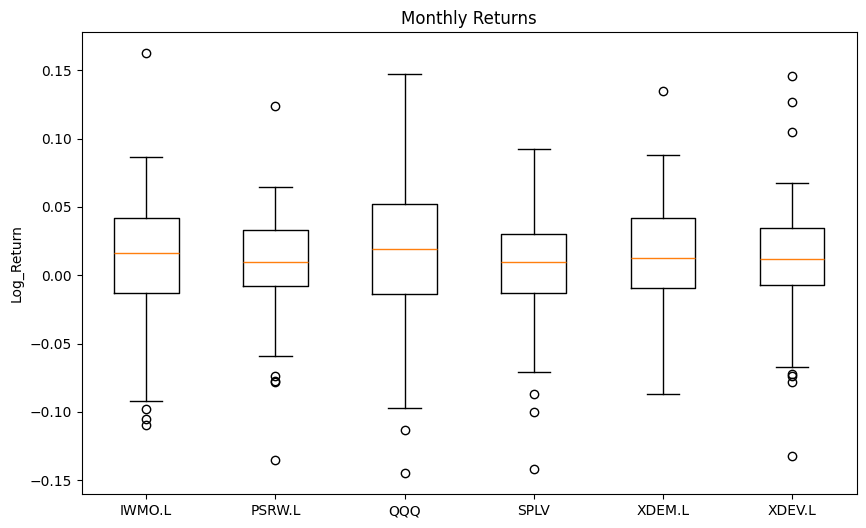

In [6]:
plt.figure(figsize=(10, 6))
plt.boxplot(log_returns, tick_labels=yftickers)

plt.title("Monthly Returns")
plt.ylabel("Log_Return")
plt.show()

In [18]:
#Now we are interested in measuring correlation between these assets
#or we can just find the covariance matrix as that will be enough
mean_returns = np.mean(log_returns, axis=0)
cent_returns = log_returns - mean_returns
cov_matrix = (cent_returns.T@cent_returns)/(log_returns.shape[0]-1)

In [22]:
for row in cov_matrix:
    print(" ".join(f"{x:8.6f}" for x in row))

0.002016 0.001008 0.002049 0.001093 0.001531 0.001034
0.001008 0.001252 0.001156 0.000785 0.000986 0.001262
0.002049 0.001156 0.002973 0.001106 0.001537 0.001155
0.001093 0.000785 0.001106 0.001364 0.000698 0.000686
0.001531 0.000986 0.001537 0.000698 0.001599 0.000988
0.001034 0.001262 0.001155 0.000686 0.000988 0.001495
